# Dự đoán mức độ trì hoãn của sinh viên khi sử dụng điện thoại

Notebook này gồm pipeline code đầy đủ:
- Đọc `train.csv`
- EDA cơ bản
- Feature engineering
- Train baseline models
- Train XGBoost và LightGBM
- So sánh kết quả
- Lưu best model, confusion matrix, feature importance

## 1. Cài thư viện

In [ ]:
# Nếu máy bạn thiếu thư viện thì bỏ dấu # và chạy:
# !pip install pandas numpy matplotlib scikit-learn joblib xgboost lightgbm

## 2. Import thư viện

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


from xgboost import XGBClassifier
HAS_XGBOOST = True


from lightgbm import LGBMClassifier
HAS_LIGHTGBM = True


## 3. Cấu hình

In [3]:
DATA_PATH = "train.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_COL = "procrastination_level"

LABEL_MAP = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
}

INV_LABEL_MAP = {
    0: "Low",
    1: "Medium",
    2: "High",
}

TARGET_NAMES = ["Low", "Medium", "High"]

## 4. Đọc và kiểm tra dữ liệu

In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nThông tin dữ liệu:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nTarget distribution:")
display(df[TARGET_COL].value_counts())

Shape: (10518, 14)


,student_id,timestamp,time_of_day,app_category,duration_minutes,is_class_time,is_study_period,is_late_night,hours_to_deadline,task_priority,assignment_count,notification_count,unlock_count,procrastination_level
0,24522824,2026-05-07 23:53:41,Night,Social,37,0,0,1,167.37,Low,5,18,6,High
1,24522824,2026-05-08 01:51:41,Night,Gaming,55,0,0,1,165.40,Medium,4,9,11,High
2,24522824,2026-05-08 04:00:41,Night,Gaming,50,0,0,1,163.25,High,0,12,4,Medium
3,24522824,2026-05-08 04:39:41,Night,Productivity,27,0,0,1,162.60,Medium,2,0,1,Low
4,24522824,2026-05-08 07:33:41,Morning,Gaming,39,1,0,0,159.70,Low,5,11,2,High



Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10518 entries, 0 to 10517
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10518 non-null  int64  
 1   timestamp              10518 non-null  object 
 2   time_of_day            10518 non-null  object 
 3   app_category           10518 non-null  object 
 4   duration_minutes       10518 non-null  int64  
 5   is_class_time          10518 non-null  int64  
 6   is_study_period        10518 non-null  int64  
 7   is_late_night          10518 non-null  int64  
 8   hours_to_deadline      10518 non-null  float64
 9   task_priority          10518 non-null  object 
 10  assignment_count       10518 non-null  int64  
 11  notification_count     10518 non-null  int64  
 12  unlock_count           10518 non-null  int64  
 13  procrastination_level  10518 non-null  object 
dtypes: float64(1), int64(8), object(5)

student_id               0
timestamp                0
time_of_day              0
app_category             0
duration_minutes         0
is_class_time            0
is_study_period          0
is_late_night            0
hours_to_deadline        0
task_priority            0
assignment_count         0
notification_count       0
unlock_count             0
procrastination_level    0
dtype: int64


Target distribution:


procrastination_level
High      4517
Low       4216
Medium    1785
Name: count, dtype: int64

## 5. EDA: Phân bố nhãn

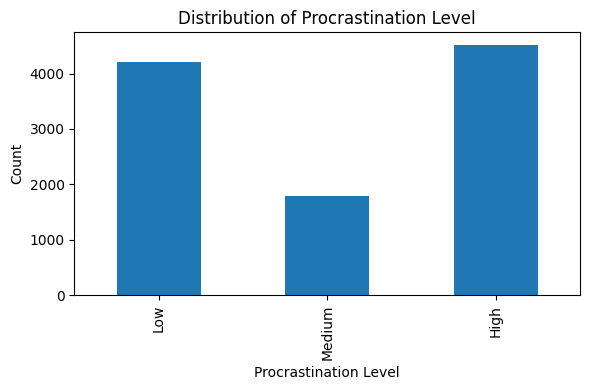

In [6]:
plt.figure(figsize=(6, 4))
df[TARGET_COL].value_counts().reindex(TARGET_NAMES).plot(kind="bar")
plt.title("Distribution of Procrastination Level")
plt.xlabel("Procrastination Level")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=300)
plt.show()

## 6. EDA: App Category và mức trì hoãn

procrastination_level,Low,Medium,High
app_category,,,
Entertainment,130,420,1441
Gaming,93,384,1320
Productivity,2746,86,0
Social,295,829,1753
System,952,66,3


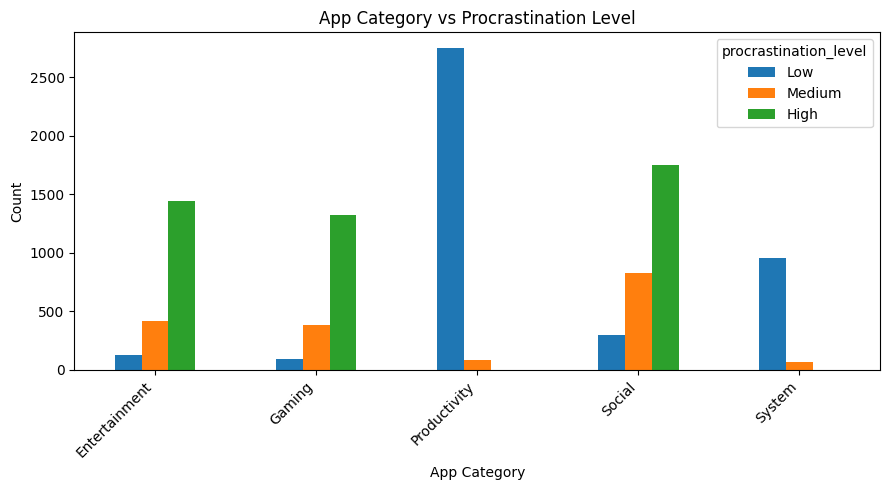

In [7]:
if "app_category" in df.columns:
    cross_tab = pd.crosstab(df["app_category"], df[TARGET_COL])
    cross_tab = cross_tab.reindex(columns=TARGET_NAMES)
    display(cross_tab)

    cross_tab.plot(kind="bar", figsize=(9, 5))
    plt.title("App Category vs Procrastination Level")
    plt.xlabel("App Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "app_category_vs_target.png", dpi=300)
    plt.show()
else:
    print("Không có cột app_category")

## 7. EDA: Thời lượng sử dụng theo mức trì hoãn

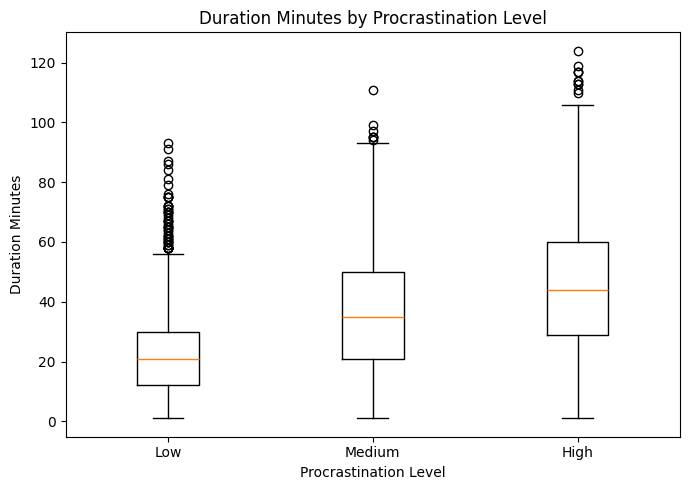

In [8]:
if "duration_minutes" in df.columns:
    data = [
        df.loc[df[TARGET_COL] == label, "duration_minutes"].dropna()
        for label in TARGET_NAMES
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(data, labels=TARGET_NAMES)
    plt.title("Duration Minutes by Procrastination Level")
    plt.xlabel("Procrastination Level")
    plt.ylabel("Duration Minutes")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "duration_by_target.png", dpi=300)
    plt.show()
else:
    print("Không có cột duration_minutes")

## 8. Feature Engineering

In [9]:
df_fe = df.copy()

if "timestamp" in df_fe.columns:
    df_fe["timestamp"] = pd.to_datetime(df_fe["timestamp"], errors="coerce")
    df_fe["hour"] = df_fe["timestamp"].dt.hour
    df_fe["day_of_week"] = df_fe["timestamp"].dt.dayofweek
    df_fe["is_weekend"] = df_fe["day_of_week"].isin([5, 6]).astype(int)

display(df_fe.head())

,student_id,timestamp,time_of_day,app_category,duration_minutes,is_class_time,is_study_period,is_late_night,hours_to_deadline,task_priority,assignment_count,notification_count,unlock_count,procrastination_level,hour,day_of_week,is_weekend
0,24522824,2026-05-07 23:53:41,Night,Social,37,0,0,1,167.37,Low,5,18,6,High,23,3,0
1,24522824,2026-05-08 01:51:41,Night,Gaming,55,0,0,1,165.40,Medium,4,9,11,High,1,4,0
2,24522824,2026-05-08 04:00:41,Night,Gaming,50,0,0,1,163.25,High,0,12,4,Medium,4,4,0
3,24522824,2026-05-08 04:39:41,Night,Productivity,27,0,0,1,162.60,Medium,2,0,1,Low,4,4,0
4,24522824,2026-05-08 07:33:41,Morning,Gaming,39,1,0,0,159.70,Low,5,11,2,High,7,4,0


## 9. Tách X và y

In [10]:
df_model = df_fe.copy()
df_model = df_model.dropna(subset=[TARGET_COL])

df_model[TARGET_COL] = df_model[TARGET_COL].map(LABEL_MAP)

if df_model[TARGET_COL].isnull().any():
    raise ValueError("Có nhãn target không hợp lệ. Kiểm tra lại cột procrastination_level.")

y = df_model[TARGET_COL].astype(int)

drop_cols = [TARGET_COL]
if "student_id" in df_model.columns:
    drop_cols.append("student_id")
if "timestamp" in df_model.columns:
    drop_cols.append("timestamp")

X = df_model.drop(columns=drop_cols)

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

display(X.head())

X shape: (10518, 14)
y shape: (10518,)

Categorical columns: ['time_of_day', 'app_category', 'task_priority']
Numerical columns: ['duration_minutes', 'is_class_time', 'is_study_period', 'is_late_night', 'hours_to_deadline', 'assignment_count', 'notification_count', 'unlock_count', 'hour', 'day_of_week', 'is_weekend']


,time_of_day,app_category,duration_minutes,is_class_time,is_study_period,is_late_night,hours_to_deadline,task_priority,assignment_count,notification_count,unlock_count,hour,day_of_week,is_weekend
0,Night,Social,37,0,0,1,167.37,Low,5,18,6,23,3,0
1,Night,Gaming,55,0,0,1,165.40,Medium,4,9,11,1,4,0
2,Night,Gaming,50,0,0,1,163.25,High,0,12,4,4,4,0
3,Night,Productivity,27,0,0,1,162.60,Medium,2,0,1,4,4,0
4,Morning,Gaming,39,1,0,0,159.70,Low,5,11,2,7,4,0


## 10. Chia train/test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8414, 14)
X_test: (2104, 14)
y_train: (8414,)
y_test: (2104,)


## 11. Preprocessing

In [12]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", onehot, categorical_cols),
        ("num", StandardScaler(), numerical_cols),
    ],
    remainder="drop",
)

## 12. Khai báo baseline models + XGBoost + LightGBM

In [13]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,
        random_state=42,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

if HAS_LIGHTGBM:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

print("Danh sách mô hình sẽ train:")
for name in models:
    print("-", name)

Danh sách mô hình sẽ train:
- Decision Tree
- Random Forest
- KNN
- Logistic Regression
- XGBoost
- LightGBM


## 13. Train và đánh giá

In [14]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("=" * 70)
    print("Training:", model_name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "model": model_name,
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
    })

    trained_pipelines[model_name] = pipeline

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision weighted: {precision:.4f}")
    print(f"Recall weighted: {recall:.4f}")
    print(f"F1 weighted: {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        target_names=TARGET_NAMES,
        zero_division=0,
    ))

results_df = pd.DataFrame(results).sort_values(by="f1_weighted", ascending=False)
results_df.to_csv(OUTPUT_DIR / "model_results.csv", index=False)

display(results_df)

Training: Decision Tree
Accuracy: 0.8013
Precision weighted: 0.7926
Recall weighted: 0.8013
F1 weighted: 0.7965

Classification report:
              precision    recall  f1-score   support

         Low       0.89      0.91      0.90       843
      Medium       0.45      0.39      0.42       357
        High       0.84      0.87      0.85       904

    accuracy                           0.80      2104
   macro avg       0.72      0.72      0.72      2104
weighted avg       0.79      0.80      0.80      2104

Training: Random Forest
Accuracy: 0.8403
Precision weighted: 0.8282
Recall weighted: 0.8403
F1 weighted: 0.8315

Classification report:
              precision    recall  f1-score   support

         Low       0.93      0.93      0.93       843
      Medium       0.56      0.42      0.48       357
        High       0.84      0.93      0.88       904

    accuracy                           0.84      2104
   macro avg       0.78      0.76      0.76      2104
weighted avg       0.

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
4,XGBoost,0.853612,0.848324,0.853612,0.850475
5,LightGBM,0.847433,0.841756,0.847433,0.844143
3,Logistic Regression,0.829848,0.861653,0.829848,0.840721
1,Random Forest,0.840304,0.828178,0.840304,0.831514
2,KNN,0.812738,0.802163,0.812738,0.805511
0,Decision Tree,0.801331,0.792646,0.801331,0.796532


## 14. Chọn best model

In [15]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model:", best_model_name)
display(results_df.iloc[[0]])

Best model: XGBoost


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
4,XGBoost,0.853612,0.848324,0.853612,0.850475


## 15. Confusion Matrix

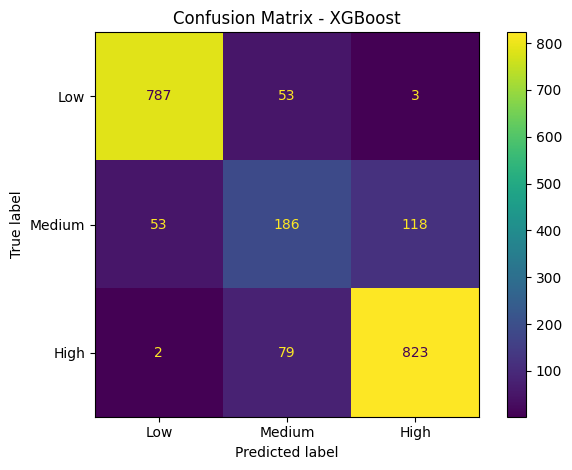

In [16]:
y_pred_best = best_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=TARGET_NAMES,
    values_format="d",
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_best_model.png", dpi=300)
plt.show()

## 16. Feature Importance

,feature,importance
6,app_category_Productivity,0.357619
8,app_category_System,0.172814
14,is_study_period,0.064557
13,is_class_time,0.052190
7,app_category_Social,0.039289
15,is_late_night,0.037132
3,time_of_day_Night,0.033042
4,app_category_Entertainment,0.031403
5,app_category_Gaming,0.028091
18,notification_count,0.021156


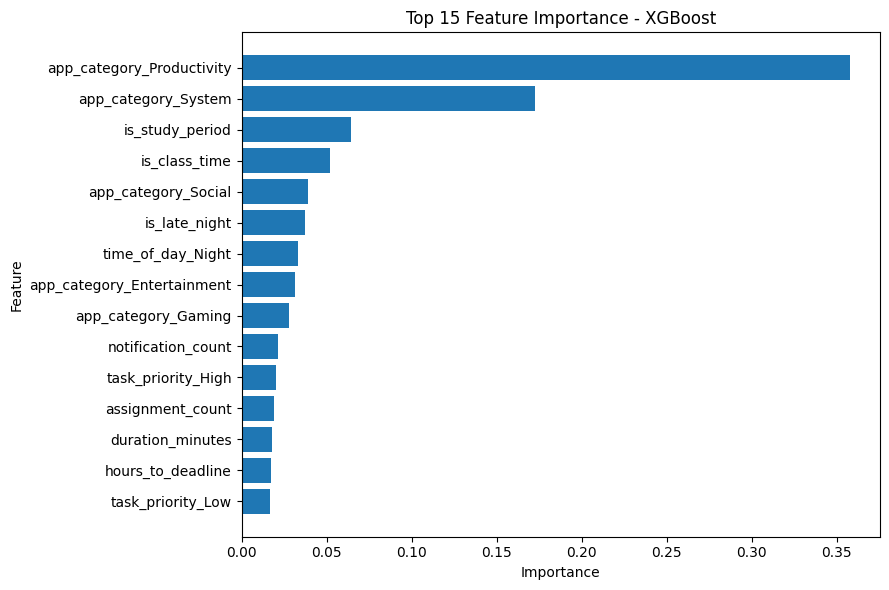

In [17]:
def get_feature_names_from_preprocessor(preprocessor, categorical_cols, numerical_cols):
    feature_names = []

    if len(categorical_cols) > 0:
        cat_encoder = preprocessor.named_transformers_["cat"]
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(cat_feature_names)

    feature_names.extend(numerical_cols)
    return feature_names


model = best_pipeline.named_steps["model"]
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

if hasattr(model, "feature_importances_"):
    feature_names = get_feature_names_from_preprocessor(
        fitted_preprocessor,
        categorical_cols,
        numerical_cols,
    )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values(by="importance", ascending=False)

    importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
    display(importance_df.head(20))

    top_n = min(15, len(importance_df))
    top_features = importance_df.head(top_n).sort_values(by="importance", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.title(f"Top {top_n} Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=300)
    plt.show()
else:
    print(f"{best_model_name} không có feature_importances_.")

## 17. Lưu best model

In [18]:
joblib.dump(best_pipeline, OUTPUT_DIR / "best_model.joblib")

with open(OUTPUT_DIR / "best_model_info.txt", "w", encoding="utf-8") as f:
    f.write(f"Best model: {best_model_name}\n")
    f.write("Label mapping:\n")
    f.write("Low -> 0\n")
    f.write("Medium -> 1\n")
    f.write("High -> 2\n")

print("Đã lưu best model vào:", OUTPUT_DIR / "best_model.joblib")

Đã lưu best model vào: outputs\best_model.joblib


## 18. Demo dự đoán một mẫu mới

In [19]:
sample = X_test.iloc[0].to_dict()
sample_df = pd.DataFrame([sample])

pred_num = best_pipeline.predict(sample_df)[0]
pred_label = INV_LABEL_MAP[int(pred_num)]

print("Input sample:")
display(sample_df)
print("Predicted procrastination level:", pred_label)

Input sample:


,time_of_day,app_category,duration_minutes,is_class_time,is_study_period,is_late_night,hours_to_deadline,task_priority,assignment_count,notification_count,unlock_count,hour,day_of_week,is_weekend
0,Night,Productivity,26,0,0,1,0.0,Medium,3,6,1,3,3,0


Predicted procrastination level: Low


## 19. Ghi chú cho report

Sau khi chạy notebook, lấy các file trong thư mục `outputs/` để đưa vào report:

- `model_results.csv`: bảng so sánh mô hình
- `confusion_matrix_best_model.png`: confusion matrix của model tốt nhất
- `feature_importance.png`: biểu đồ đặc trưng quan trọng
- `best_model_info.txt`: thông tin model tốt nhất
- `best_model.joblib`: model đã lưu